In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## P1 — Load, Clean & Merge 

In [35]:
tickets = pd.read_csv("tickets.csv")
teams = pd.read_csv("teams.csv")

In [36]:
tickets.head()

,ticket_id,month,team_id,channel,resolution_hours,satisfaction
0,1,Jan,T1,Email,12,4
1,2,Jan,T2,Chat,28,3
2,3,Jan,T3,Phone,36,2
3,4,Jan,T4,Email,20,4
4,5,Feb,T1,Chat,8,5


In [37]:
teams.head()

,team_id,team,department
0,T1,AccountCare,Service
1,T2,BillingHelp,Service
2,T3,AppSupport,Technical
3,T4,DeviceHelp,Technical


In [38]:
tickets.isna().sum()

ticket_id           0
month               0
team_id             0
channel             0
resolution_hours    0
satisfaction        0
dtype: int64

In [39]:
tickets.shape

(13, 6)

In [40]:
teams.shape

(4, 3)

In [53]:
tickets_clean = tickets.drop_duplicates()
tickets_clean.shape

(12, 6)

In [56]:
merged = tickets_clean.merge(teams, on='team_id', how='left')
print(merged)

    ticket_id month team_id channel  resolution_hours  satisfaction  \
0           1   Jan      T1   Email                12             4   
1           2   Jan      T2    Chat                28             3   
2           3   Jan      T3   Phone                36             2   
3           4   Jan      T4   Email                20             4   
4           5   Feb      T1    Chat                 8             5   
5           6   Feb      T2   Phone                30             3   
6           7   Feb      T3   Email                18             4   
7           8   Feb      T4    Chat                40             2   
8           9   Mar      T1   Phone                16             4   
9          10   Mar      T2   Email                22             4   
10         11   Mar      T3    Chat                32             3   
11         12   Mar      T4   Phone                24             5   

           team department  
0   AccountCare    Service  
1   BillingHelp   

In [61]:
assert len(merged) == 12, f'Expected 12 rows, got {len(merged)}'
assert merged['department'].isna().sum() == 0, 'Unmatched team_id — NaN in department!'
print({len(merged)})

merged

{12}


,ticket_id,month,team_id,channel,resolution_hours,satisfaction,team,department
0,1,Jan,T1,Email,12,4,AccountCare,Service
1,2,Jan,T2,Chat,28,3,BillingHelp,Service
2,3,Jan,T3,Phone,36,2,AppSupport,Technical
3,4,Jan,T4,Email,20,4,DeviceHelp,Technical
4,5,Feb,T1,Chat,8,5,AccountCare,Service
5,6,Feb,T2,Phone,30,3,BillingHelp,Service
6,7,Feb,T3,Email,18,4,AppSupport,Technical
7,8,Feb,T4,Chat,40,2,DeviceHelp,Technical
8,9,Mar,T1,Phone,16,4,AccountCare,Service
9,10,Mar,T2,Email,22,4,BillingHelp,Service


## P2 — Derived Field & Department Analysis 

In [63]:
# Derived field: breach_flag = 1 when resolution_hours > 24, else 0
merged['breach_flag'] = (merged['resolution_hours'] > 24).astype(int)

print('breach_flag rule: resolution_hours > 24 → 1, else → 0')
merged[['ticket_id','team_id','channel','resolution_hours','satisfaction','department','breach_flag']]

breach_flag rule: resolution_hours > 24 → 1, else → 0


,ticket_id,team_id,channel,resolution_hours,satisfaction,department,breach_flag
0,1,T1,Email,12,4,Service,0
1,2,T2,Chat,28,3,Service,1
2,3,T3,Phone,36,2,Technical,1
3,4,T4,Email,20,4,Technical,0
4,5,T1,Chat,8,5,Service,0
5,6,T2,Phone,30,3,Service,1
6,7,T3,Email,18,4,Technical,0
7,8,T4,Chat,40,2,Technical,1
8,9,T1,Phone,16,4,Service,0
9,10,T2,Email,22,4,Service,0


In [65]:
# Department-level summary
dept_summary = merged.groupby('department').agg(
    total_tickets    = ('ticket_id', 'count'),
    breach_count     = ('breach_flag', 'sum'),
    avg_resolution   = ('resolution_hours', 'mean'),
    avg_satisfaction = ('satisfaction', 'mean')
).reset_index()

dept_summary['sla_breach_rate_pct'] = (
    dept_summary['breach_count'] / dept_summary['total_tickets'] * 100
).round(2)
dept_summary['avg_resolution']   = dept_summary['avg_resolution'].round(2)
dept_summary['avg_satisfaction'] = dept_summary['avg_satisfaction'].round(2)

print('── Department Summary ──')
dept_summary

── Department Summary ──


,department,total_tickets,breach_count,avg_resolution,avg_satisfaction,sla_breach_rate_pct
0,Service,6,2,19.33,3.83,33.33
1,Technical,6,3,28.33,3.33,50.00


In [67]:
# Team-level breach analysis
team_summary = merged.groupby(['team_id','team','department']).agg(
    total_tickets = ('ticket_id', 'count'),
    breach_count  = ('breach_flag', 'sum')
).reset_index()
team_summary['breach_rate_pct'] = (
    team_summary['breach_count'] / team_summary['total_tickets'] * 100
).round(2)

# Identify team with highest breach rate
highest = team_summary.loc[team_summary['breach_rate_pct'].idxmax()]
print(f'Highest SLA breach rate team : {highest["team"]} ({highest["team_id"]})')
print(f'  Breached: {int(highest["breach_count"])} / {int(highest["total_tickets"])} '
      f'= {highest["breach_rate_pct"]}%\n')
team_summary

Highest SLA breach rate team : BillingHelp (T2)
  Breached: 2 / 3 = 66.67%



,team_id,team,department,total_tickets,breach_count,breach_rate_pct
0,T1,AccountCare,Service,3,0,0.00
1,T2,BillingHelp,Service,3,2,66.67
2,T3,AppSupport,Technical,3,2,66.67
3,T4,DeviceHelp,Technical,3,1,33.33


In [68]:
# Channel-level breach summary
channel_summary = merged.groupby('channel').agg(
    total_tickets = ('ticket_id', 'count'),
    breach_count  = ('breach_flag', 'sum')
).reset_index()
channel_summary['breach_rate_pct'] = (
    channel_summary['breach_count'] / channel_summary['total_tickets'] * 100
).round(2)

# Overall SLA breach rate (cross-tool reconciliation anchor)
overall_breach_rate = merged['breach_flag'].sum() / len(merged) * 100
print(f'Overall SLA Breach Rate: {overall_breach_rate:.2f}%  '
      f'({merged["breach_flag"].sum()} breached / {len(merged)} total)\n')
channel_summary

Overall SLA Breach Rate: 41.67%  (5 breached / 12 total)



,channel,total_tickets,breach_count,breach_rate_pct
0,Chat,4,3,75.0
1,Email,4,0,0.0
2,Phone,4,2,50.0


## P3 — Chart & Exports 

In [74]:
month_order = ['Jan', 'Feb', 'Mar']
merged['month'] = pd.Categorical(merged['month'], categories=month_order, ordered=True)

# Monthly average resolution hours
monthly_avg = (
    merged.groupby('month', observed=True)['resolution_hours'].mean().reindex(month_order).round(2))

print('Monthly Avg Resolution Hours:')
print(monthly_avg.to_string())

Monthly Avg Resolution Hours:
month
Jan    24.0
Feb    24.0
Mar    23.5


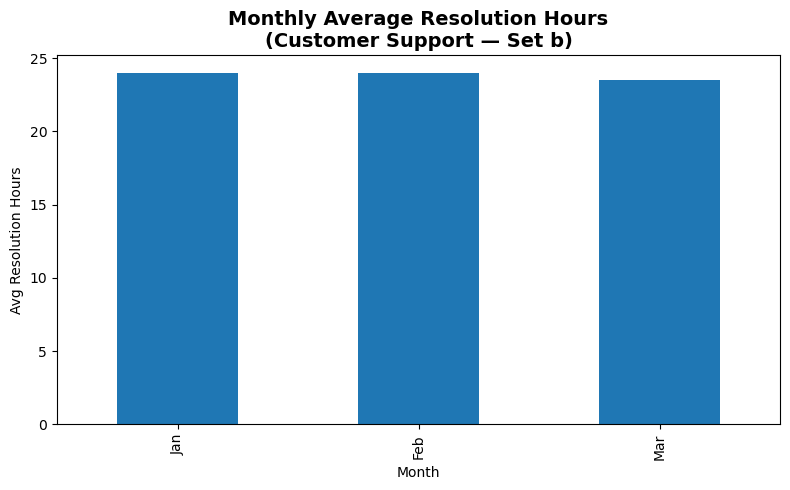

In [82]:
plt.figure(figsize=(8, 5))

monthly_avg.plot(kind="bar")

plt.title("Monthly Average Resolution Hours\n(Customer Support — Set b)",
             fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Avg Resolution Hours")

plt.tight_layout()
plt.savefig("outputs/python_chart.png")
plt.show()

In [83]:
# Export clean merged data and department summary
merged.to_csv('outputs/clean_data.csv', index=False)
dept_summary.to_csv('outputs/python_summary.csv', index=False)